Dataset: https://www.kaggle.com/datasets/ludocielbeckett/health-risk-prediction-anonymized-real-data/data

# Import libraries

In [1]:
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network  import MLPRegressor

import joblib

# Data analysis

In [43]:
# Load data
df = pd.read_csv("../../../../data/Health_Risk_Dataset.csv")
df.columns=df.columns.str.lower()
df.head()

,patient_id,respiratory_rate,oxygen_saturation,o2_scale,systolic_bp,heart_rate,temperature,consciousness,on_oxygen,risk_level
0,P0522,25,96,1,97,107,37.5,A,0,Medium
1,P0738,28,92,2,116,151,38.5,P,1,High
2,P0741,29,91,1,79,135,38.4,A,0,High
3,P0661,24,96,1,95,92,37.3,A,0,Medium
4,P0412,20,96,1,97,97,37.4,A,0,Low


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         1000 non-null   str    
 1   respiratory_rate   1000 non-null   int64  
 2   oxygen_saturation  1000 non-null   int64  
 3   o2_scale           1000 non-null   int64  
 4   systolic_bp        1000 non-null   int64  
 5   heart_rate         1000 non-null   int64  
 6   temperature        1000 non-null   float64
 7   consciousness      1000 non-null   str    
 8   on_oxygen          1000 non-null   int64  
 9   risk_level         1000 non-null   str    
dtypes: float64(1), int64(6), str(3)
memory usage: 78.3 KB


In [5]:
df['risk'].value_counts()

risk
1    585
0    415
Name: count, dtype: int64

In [5]:
df.isnull().sum()

patient_id           0
respiratory_rate     0
oxygen_saturation    0
o2_scale             0
systolic_bp          0
heart_rate           0
temperature          0
consciousness        0
on_oxygen            0
risk_level           0
dtype: int64

In [6]:
df.describe()

,respiratory_rate,oxygen_saturation,o2_scale,systolic_bp,heart_rate,temperature,on_oxygen
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,21.511000,92.59000,1.124000,106.160000,98.460000,37.921000,0.274000
std,5.287517,4.47302,0.329746,17.897562,19.694626,1.113696,0.446232
min,12.000000,74.00000,1.000000,50.000000,60.000000,35.600000,0.000000
25%,17.000000,90.00000,1.000000,94.000000,84.000000,37.100000,0.000000
50%,20.000000,94.00000,1.000000,109.000000,95.500000,37.800000,0.000000
75%,25.000000,96.00000,1.000000,119.000000,109.000000,38.600000,1.000000
max,40.000000,100.00000,2.000000,146.000000,163.000000,41.800000,1.000000


# Preprocessing

Change column "Consciousness" from Categorical to Numerical

In [ ]:
# df['consciousness'] = df['consciousness'].str.upper().str.strip()
# conscious_map = {'A': 0, 'V': 1, 'P': 2, 'C': 3, 'U': 4}
# df['consciousness'] = df['consciousness'].map(conscious_map)

# print(df['consciousness'].isnull().sum())
# risk_map = {'High Risk': 1, "Low Risk": 0}
# df["risk"] = df["risk category"].map(risk_map)
# df.drop("risk category", axis=1, inplace=True)

In [44]:
df["risk"] = ((df["risk_level"] == "High") | (df["risk_level"] == "Medium")).astype(int)
df.drop(["risk_level", "o2_scale", "consciousness", "patient_id", "on_oxygen"],  axis=1, inplace=True)

# df["shock_index"] = df["heart rate"] / df["systolic blood pressure"]

# df["map"] = (df["systolic blood pressure"] + 2 * df["diastolic blood pressure"]) / 3

# df["pulse_pressure_ratio"] = df["derived_pulse_pressure"] / df["systolic blood pressure"]

# df["hr_oxygen_stress"] = df["heart rate"] * (100 - df["oxygen saturation"])

# df["temp_hr_interaction"] = df["body temperature"] * df["heart rate"]
# df["log_hrv"] = np.log1p(df["derived_hrv"])
# df["hr_squared"] = df["heart rate"] ** 2
# df["pulse_pressure_ratio"] = df["derived_pulse_pressure"] / df["systolic blood pressure"]

# df.drop(["patient id", "age", "gender", "timestamp"],  axis=1, inplace=True)
# df.drop(["derived_hrv", "derived_pulse_pressure","derived_map", "derived_bmi", "weight (kg)", "height (m)"],  axis=1, inplace=True)
# "derived_hrv", "derived_pulse_pressure", "weight (kg)", "height (m)"
df

,respiratory_rate,oxygen_saturation,systolic_bp,heart_rate,temperature,risk
0,25,96,97,107,37.5,1
1,28,92,116,151,38.5,1
2,29,91,79,135,38.4,1
3,24,96,95,92,37.3,1
4,20,96,97,97,37.4,0
...,...,...,...,...,...,...
995,18,96,124,72,37.2,0
996,19,95,129,70,38.1,0
997,39,82,101,137,37.5,1
998,15,92,106,108,38.6,1


In [45]:
# drop patient_id since it does not influence the health risk
# df.drop('patient_id', axis=1, inplace=True)

scaler = StandardScaler()
num_cols = df.drop('risk', axis=1).select_dtypes(include='number').columns
df[num_cols] = scaler.fit_transform(df[num_cols])

Cross-correlation

<Axes: >

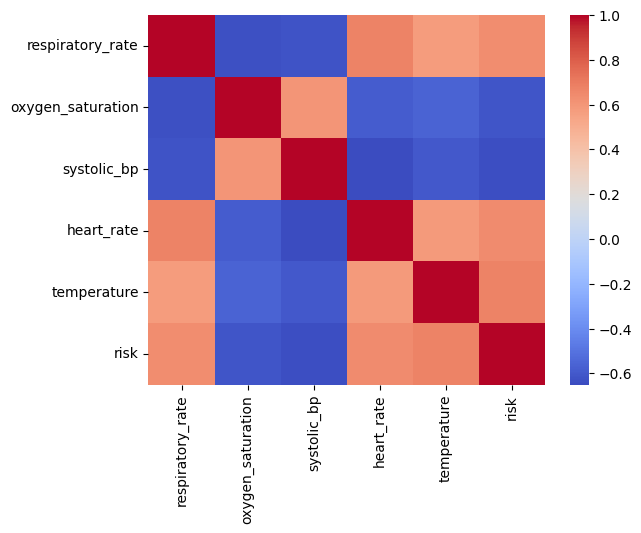

In [46]:
sns.heatmap(df.corr(), cmap='coolwarm')

# Training and evaluating model

In [47]:
X = df.drop('risk', axis=1)
y = df['risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

### Random Forest

In [48]:
teacher = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,          # limit overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

teacher.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [ ]:
# # XGBoost
# import xgboost as xgb
# teacher = xgb.XGBClassifier(
#     n_estimators=800,
#     max_depth=4,
#     learning_rate=0.03,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     scale_pos_weight=1.1,
#     random_state=42
# )

# teacher.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Distillation

In [49]:
# Temperature scaling: T > 1 softens probabilities, transferring more nuance
T = 2.0
raw_proba   = teacher.predict_proba(X_train)          # shape (N, 2)
soft_labels = raw_proba ** (1.0 / T)                  # soften
soft_labels = soft_labels / soft_labels.sum(axis=1, keepdims=True)  # renormalise

print(f"Soft label sample (first 5 rows):\n   {soft_labels[:5].round(3)}")
print(f"Temperature T={T} → labels are softer, more informative than hard 0/1")

Soft label sample (first 5 rows):
   [[0.189 0.811]
 [0.971 0.029]
 [0.    1.   ]
 [0.214 0.786]
 [0.    1.   ]]
Temperature T=2.0 → labels are softer, more informative than hard 0/1


In [50]:
# scaler  = StandardScaler()
# X_train_s = scaler.fit_transform(X_train)
# X_test_s  = scaler.transform(X_test)
# MLPRegressor: trains on soft probabilities [0,1] from the teacher
student_mlp = MLPRegressor(
    hidden_layer_sizes = (16, 8),      # two tiny hidden layers → fits ESP32 SRAM
    activation         = "relu",
    solver             = "adam",
    alpha              = 1e-3,         # L2 regularisation
    learning_rate_init = 1e-3,
    max_iter           = 1000,
    random_state       = 42,
    early_stopping     = True,
    validation_fraction= 0.1,
    n_iter_no_change   = 20,
    verbose            = False,
)
student_mlp.fit(X_train, soft_labels[:, 1])

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [54]:
teacher_proba = teacher.predict_proba(X_test)[:,1]
teacher_pred = (teacher_proba > 0.44).astype(int)
print(classification_report(y_test, teacher_pred))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96        83
           1       0.95      0.99      0.97       117

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200



In [73]:
student_proba = student_mlp.predict(X_test).clip(0, 1)
student_pred  = (student_proba > 0.41).astype(int)
print(classification_report(y_test, student_pred))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        83
           1       0.93      1.00      0.96       117

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200



In [74]:
## Evaluation
 
t_f1  = f1_score(y_test, teacher_pred)
s_f1  = f1_score(y_test, student_pred)
t_auc = roc_auc_score(y_test, teacher_proba)
s_auc = roc_auc_score(y_test, student_proba)
 
print(f"{'Metric':<20} {'Teacher (RF)':<18} {'Student (MLP)'}")
print(f"{'F1 Score':<20} {t_f1:<18.4f} {s_f1:.4f}")
print(f"{'ROC-AUC':<20} {t_auc:<18.4f} {s_auc:.4f}")
print(f"\nStudent classification report:")
print(classification_report(y_test, student_pred, target_names=["Normal", "Anomaly"]))
 
retention = (s_f1 / t_f1) * 100
print(f"Knowledge retention: {retention:.1f}% of teacher F1 preserved")

Metric               Teacher (RF)       Student (MLP)
F1 Score             0.9707             0.9630
ROC-AUC              0.9925             0.9988

Student classification report:
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94        83
     Anomaly       0.93      1.00      0.96       117

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200

Knowledge retention: 99.2% of teacher F1 preserved


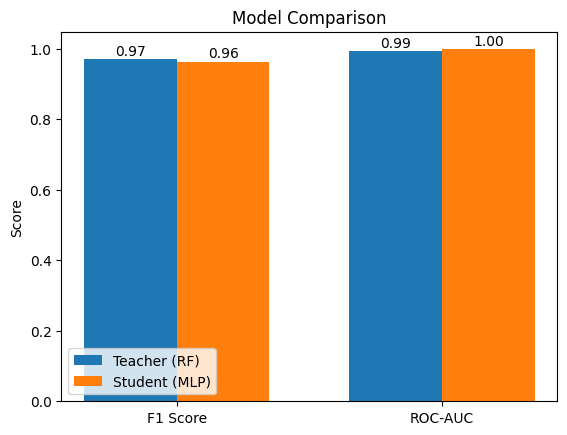

In [76]:
metrics = ["F1 Score", "ROC-AUC"]
teacher_scores = [t_f1, t_auc]
student_scores = [s_f1, s_auc]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots()

bars1 = ax.bar(x - width/2, teacher_scores, width, label="Teacher (RF)")
bars2 = ax.bar(x + width/2, student_scores, width, label="Student (MLP)")

ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Add values on top
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center')

plt.show()

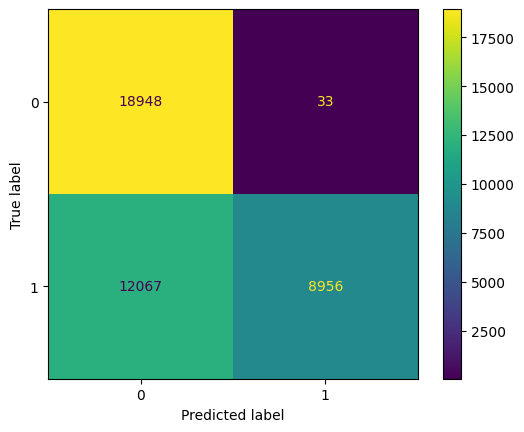

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(teacher, X_test, y_test)
# ConfusionMatrixDisplay.from_estimator(student_mlp, X_test, y_test)

In [19]:
accuracy = accuracy_score(y_test, teacher_pred)
print(f"Teacher Model Accuracy: {accuracy * 100:.2f}%")
accuracy = accuracy_score(y_test, student_pred)
print(f"Student Model Accuracy: {accuracy * 100:.2f}%")

Teacher Model Accuracy: 95.50%
Student Model Accuracy: 97.00%


In [53]:
from sklearn.metrics import f1_score, recall_score

best_f1 = 0
best_t = 0

for t in [i/100 for i in range(20, 60)]:
    y_pred = (teacher_proba > t).astype(int)

    recall_0 = recall_score(y_test, y_pred, pos_label=0)
    f1 = f1_score(y_test, y_pred)

    if recall_0 > 0.6 and f1 > best_f1:
        best_f1 = f1
        best_t = t

print(best_t, best_f1)

0.44 0.9707112970711297


In [20]:
cm      = confusion_matrix(y_test, student_pred)
roc_auc = roc_auc_score(y_test, student_proba)
f1      = f1_score(y_test, student_pred)

print(f"Confusion Matrix:\n{cm}")
print(f"\nROC-AUC : {roc_auc:.4f}")
print(f"F1 Score: {f1:.4f}")

cv_scores = cross_val_score(teacher, X, y, cv=5, scoring="f1")
print(f"\n5-Fold Cross-Val F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Confusion Matrix:
[[ 79   4]
 [  2 115]]

ROC-AUC : 0.9988
F1 Score: 0.9746

5-Fold Cross-Val F1: 0.9710 ± 0.0106


# Export model

In [21]:
joblib.dump(student_mlp, "cloud_model.1.0.1/cloud_model.1.0.1.pkl")

['cloud_model.1.0.1/cloud_model.1.0.1.pkl']

In [22]:
# Save the scaler 
joblib.dump(scaler, "cloud_model.1.0.1/standard_scaler.pkl")

['cloud_model.1.0.1/standard_scaler.pkl']

In [23]:
feature_cols = df.columns[:-1]
feature_cols

Index(['respiratory_rate', 'oxygen_saturation', 'systolic_bp', 'heart_rate',
       'temperature'],
      dtype='str')

In [24]:
metadata = {
    "model_version"  : "1.0.1",
    "model_type"     : "MLPRegressor",
    "feature_columns": feature_cols.tolist(),
    "target_column"  : "anomaly",
    # "optimal_threshold": round(float(best_thresh), 3),
    "normal_ranges"  : {
        "systolic_bp" : {"min": 90,  "max": 139},
        "heart_rate"              : {"min": 55,  "max": 100},
        "temperature"        : {"min": 36.0,"max": 37.5},
        "oxygen_saturation"       : {"min": 95,  "max": 100},
        "respiratory_rate"        : {"min": 12, "max":25},
        # "o2_scale"                : {},
    },
    "performance": {
    "roc_auc"        : round(roc_auc, 4),
    "f1_score"       : round(f1, 4),
    "cv_f1_mean"     : round(float(cv_scores.mean()), 4),
    "cv_f1_std"      : round(float(cv_scores.std()),  4),
    },
    "edge_deployment": {
    "target_device" : " esp32",
    "inference_format": "sklearn Pipeline (.pkl)",
    "real_device_export": "Convert via tf.lite or onnxmltools for hardware",
    },
}

with open("cloud_model.1.0.1/metadata_cloud_model.json", "w") as f:
    json.dump(metadata, f, indent=2)

In [25]:
importances = teacher.feature_importances_
feat_imp = sorted(zip(df.columns[:-1], importances), key=lambda x: -x[1])
print("\n Feature Importances:")
for feat, imp in feat_imp:
    bar = "█" * int(imp * 40)
    print(f"  {feat:<32} {imp:.4f}  {bar}")


 Feature Importances:
  temperature                      0.3532  ██████████████
  oxygen_saturation                0.2659  ██████████
  respiratory_rate                 0.1510  ██████
  heart_rate                       0.1338  █████
  systolic_bp                      0.0961  ███
